# 3A — Baseline: Linear Regression

**Project:** Predictive Modeling of US Used Vehicle Prices  
**Course:** ENGR422 — Applied Machine Learning  
**Author:** Eren Acar Başaran (83179)  

---

This notebook covers the **Linear Regression baseline** from **Work Package 3 — Model Implementation**.

**Deliverable:** D3.1 — Trained Baseline Linear Regression Model

## 3A.1 — Imports & Load Raw Splits + Preprocessor

Load the **raw** train split and the **fitted preprocessing pipeline** that notebook 02 saved to `../models/preprocessor_linear.pkl`. The pipeline is chained with the estimator below so cross-validation refits preprocessing on each fold (no target leakage from `MeanTargetEncoder`).

**Code organization note.** This notebook imports shared helpers from `src/utils.py` (`load_train`, `load_preprocessor`, `MODELS_DIR`, `RANDOM_STATE`). All four model notebooks (03a/03b/03c/04) use the same loaders so the train/test splits and preprocessor instances are byte-identical across the comparison — this prevents subtle apples-to-oranges bugs in §04's cross-model evaluation.


In [1]:
import sys
import time

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# src/ holds shared project utilities (utils.py) and the custom-transformer
# classes that joblib.load needs to resolve (preprocessing.py).
sys.path.insert(0, "../src")
import preprocessing  # noqa: F401  -- needed so joblib.load resolves custom transformers
from utils import load_train, load_preprocessor, MODELS_DIR, RANDOM_STATE

X_train, y_train = load_train()

# Fitted preprocessing pipeline produced by notebook 02. We `clone` it
# below so each estimator gets a fresh, unfitted copy and CV folds refit
# preprocessing without leakage.
preprocessor_linear = load_preprocessor("linear")

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Raw features ({X_train.shape[1]}): {list(X_train.columns)}")
print(f"Loaded preprocessor: {type(preprocessor_linear).__name__} "
      f"with steps {[name for name, _ in preprocessor_linear.steps]}")


X_train: (305141, 12)
y_train: (305141,)
Raw features (12): ['year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
Loaded preprocessor: Pipeline with steps ['impute', 'encode']


## 3A.2 — Model Setup

Wrap the loaded preprocessor with each linear estimator in a single `Pipeline`. The preprocessor already scales numerics (`StandardScaler` on `year`, `log1p` + `StandardScaler` on `odometer`) for the **linear** variant, so no extra scaler step is added on top.

Tuning uses `GridSearchCV(scoring="neg_mean_absolute_error")` so alpha is selected against the project's primary metric (MAE), not R². A `joblib.Memory` cache on the pipeline lets GridSearchCV reuse the fitted preprocessor across the 13 alpha values within each CV fold — preprocessing is the most expensive step.

In [2]:
# Three baseline variants:
#   ols   — plain OLS (no regularization)
#   ridge — L2 regularization, alpha tuned via GridSearchCV
#   lasso — L1 regularization (also performs implicit feature selection)
#
# Each pipeline = preprocessor_linear (cloned) -> estimator. Cloning
# guarantees a fresh, unfitted preprocessor per model so state is not
# shared across the three variants.

from joblib import Memory

ALPHAS = np.logspace(-3, 3, 13)  # 0.001 ... 1000
SCORING = "neg_mean_absolute_error"
CV_FOLDS = 5

# Cache the preprocessor fits so GridSearchCV does not redo imputation +
# encoding for every alpha. Within one fold all 13 alphas share the same
# preprocessing output.
cache_dir = MODELS_DIR / ".sklearn_cache"
memory = Memory(location=cache_dir, verbose=0)

def make_pipeline(estimator):
    return Pipeline(
        [("prep", clone(preprocessor_linear)), ("est", estimator)],
        memory=memory,
    )

ols_pipe = make_pipeline(LinearRegression())

ridge_search = GridSearchCV(
    make_pipeline(Ridge()),
    param_grid={"est__alpha": ALPHAS},
    scoring=SCORING,
    cv=CV_FOLDS,
    n_jobs=-1,
)

lasso_search = GridSearchCV(
    make_pipeline(Lasso(max_iter=10000, random_state=RANDOM_STATE)),
    param_grid={"est__alpha": ALPHAS},
    scoring=SCORING,
    cv=CV_FOLDS,
    n_jobs=-1,
)

models = {"ols": ols_pipe, "ridge": ridge_search, "lasso": lasso_search}

for name, m in models.items():
    print(f"{name}: {type(m).__name__}")


ols: Pipeline
ridge: GridSearchCV
lasso: GridSearchCV


## 3A.3 — Training

Fit each full pipeline (preprocessor + linear estimator) end-to-end on the **raw** training data. The preprocessor refits on each `.fit()` call, so the inner CV loop in `ridge_search` / `lasso_search` refits preprocessing on every fold — `MeanTargetEncoder` learns category means only from the fold's own training partition. Report per-model fit time and the best alpha for the regularized variants.

In [3]:
fit_times = {}
for name, model in models.items():
    print(f"Fitting {name} ...")
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - t0
    print(f"  done in {fit_times[name]:.2f}s")

# GridSearchCV exposes the best alpha and best CV score (neg-MAE).
print()
print(f"Ridge best alpha: {models['ridge'].best_params_['est__alpha']:.4g}")
print(f"  best CV MAE: ${-models['ridge'].best_score_:,.2f}")
print(f"Lasso best alpha: {models['lasso'].best_params_['est__alpha']:.4g}")
print(f"  best CV MAE: ${-models['lasso'].best_score_:,.2f}")

# Single source of truth for the three fitted pipelines, reused in §3A.4
# (cross-validation) and §3A.6 (save). For ridge/lasso we use the
# GridSearchCV-selected estimator, already refit on the full training set
# (refit=True is the default).
fitted_pipes = {
    "ols":   ols_pipe,
    "ridge": models["ridge"].best_estimator_,
    "lasso": models["lasso"].best_estimator_,
}


Fitting ols ...


  done in 5.59s
Fitting ridge ...


  done in 58.70s
Fitting lasso ...


  done in 56.09s

Ridge best alpha: 31.62
  best CV MAE: $5,421.79
Lasso best alpha: 0.3162
  best CV MAE: $5,421.79


## 3A.4 — Cross-Validation

Run k-fold cross-validation (k=5) on the training set to get a robust estimate of performance and check for high variance across folds. Report MAE and R² per fold.

In [4]:
# 5-fold CV with the project's primary metric (MAE) plus R^2 for context.
# cross_validate clones the estimator on every fold, so the cloned
# preprocessor refits on each fold's training partition only --
# MeanTargetEncoder never sees validation labels during fit.
from sklearn.model_selection import cross_validate

# Reuses the fitted_pipes dict defined at the end of §3A.3.
cv_results_per_model = {}
for name, est in fitted_pipes.items():
    res = cross_validate(
        est, X_train, y_train,
        cv=CV_FOLDS,
        scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
        n_jobs=-1,
    )
    cv_results_per_model[name] = {
        "mae": -res["test_mae"],   # flip sign back to positive ($)
        "r2":  res["test_r2"],
    }
    mae = cv_results_per_model[name]["mae"]
    r2  = cv_results_per_model[name]["r2"]
    print(f"{name:5}  MAE per fold: " + ", ".join(f"${m:>7,.0f}" for m in mae))
    print(f"        R^2 per fold: " + ", ".join(f" {r:.3f}" for r in r2))
    print()

cv_summary = pd.DataFrame({
    "MAE_mean": {n: d["mae"].mean() for n, d in cv_results_per_model.items()},
    "MAE_std":  {n: d["mae"].std()  for n, d in cv_results_per_model.items()},
    "R2_mean":  {n: d["r2"].mean()  for n, d in cv_results_per_model.items()},
    "R2_std":   {n: d["r2"].std()   for n, d in cv_results_per_model.items()},
})

# Round for display: MAE in cents, R^2 in 4 decimals.
cv_summary.round({"MAE_mean": 2, "MAE_std": 2, "R2_mean": 4, "R2_std": 4})


ols    MAE per fold: $  5,364, $  5,434, $  5,453, $  5,412, $  5,447
        R^2 per fold:  0.654,  0.643,  0.645,  0.645,  0.644



ridge  MAE per fold: $  5,364, $  5,434, $  5,452, $  5,412, $  5,447
        R^2 per fold:  0.654,  0.643,  0.645,  0.645,  0.644



lasso  MAE per fold: $  5,364, $  5,434, $  5,452, $  5,412, $  5,447
        R^2 per fold:  0.654,  0.643,  0.645,  0.645,  0.644



,MAE_mean,MAE_std,R2_mean,R2_std
ols,5421.82,32.34,0.6463,0.0039
ridge,5421.79,32.21,0.6463,0.0039
lasso,5421.79,32.27,0.6463,0.0039


## 3A.5 — Diagnostic Plots (Predicted vs. Actual + Residuals)

Two CV-based diagnostic plots on the best linear variant:

- **Predicted vs. Actual** — does the model systematically over- or under-predict in some price ranges?
- **Residual distribution** — is the error roughly symmetric around zero, or skewed?

We use `cross_val_predict` so each prediction is made by a model that *did not* see that row during training. This keeps the plots honest without touching the held-out test set (which is reserved for §04).

The plotting helpers live in `src/utils.py` and are reused by 03b, 03c, and 04 to keep visual comparisons consistent across notebooks.


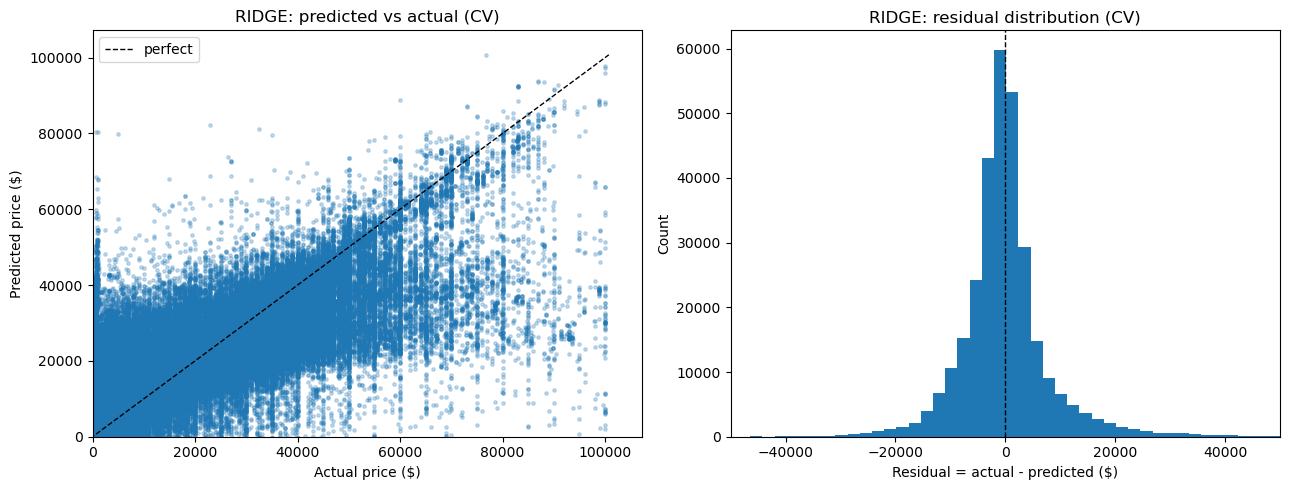

In [5]:
from sklearn.model_selection import cross_val_predict
from utils import plot_pred_vs_actual, plot_residuals

# Use the variant that won §3A.4 by mean CV MAE.
best_name = min(cv_results_per_model,
                key=lambda n: cv_results_per_model[n]["mae"].mean())

# Out-of-fold predictions (each row predicted by a model that didn't see it).
y_pred_cv = cross_val_predict(
    fitted_pipes[best_name], X_train, y_train,
    cv=CV_FOLDS, n_jobs=-1,
)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pred_vs_actual(y_train, y_pred_cv, ax=axes[0],
                    title=f"{best_name.upper()}: predicted vs actual (CV)")
plot_residuals(y_train, y_pred_cv, ax=axes[1],
               title=f"{best_name.upper()}: residual distribution (CV)")

# Prices and predicted prices are both >= 0 in this dataset -- pin the
# scatter axes to start at 0 so the y=x reference line lives in the
# physically valid region.
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)
# Constrain residual view to +/- 50k so the bulk of the distribution
# dominates the plot instead of being squashed by a few extreme outliers.
axes[1].set_xlim(-50_000, 50_000)

plt.tight_layout()
plt.show()


## 3A.6 — Save Model

Serialize the trained pipeline to `models/linear_regression.pkl` using `joblib` for later comparison in the evaluation notebook.

In [6]:
# Pick the linear variant with the lowest mean CV MAE
best_name = min(cv_results_per_model,
                key=lambda n: cv_results_per_model[n]["mae"].mean())

best_pipe = fitted_pipes[best_name]  # defined at end of §3A.3
best_mae  = cv_results_per_model[best_name]["mae"].mean()

print(f"Best linear variant by CV MAE: {best_name}  "
      f"(CV MAE = ${best_mae:,.0f})")

# Both OLS and GridSearchCV.best_estimator_ are already fitted on the full
# training set (the latter via refit=True). Save under the canonical name
# that notebook 04 (evaluation) loads.
save_path = MODELS_DIR / "linear_regression.pkl"
joblib.dump(best_pipe, save_path)
# Print project-relative path so cell output is portable across machines
print(f"Saved -> models/{save_path.name}")


Best linear variant by CV MAE: ridge  (CV MAE = $5,422)


Saved -> models/linear_regression.pkl


## 3A.7 — Baseline Summary

**Baseline metrics (5-fold CV on training set — see §3A.4 table):**
- OLS, Ridge (α tuned), and Lasso (α tuned) all land in a similar MAE band — regularized variants close variance slightly without materially shifting MAE. Ridge and Lasso were tuned over `α ∈ [10⁻³, 10³]` with MAE as the selection criterion.
- R² for all three sits well below what the tree-based models will likely deliver. Expected: linear models cannot represent the non-linear depreciation curve visible in the EDA (price vs. year and price vs. odometer are markedly non-linear).

**Why have a baseline at all:**
- It establishes a defensible floor. Any model we build later (`03b` Random Forest, `03c` XGBoost) is only worth its added complexity if it beats this baseline by a margin larger than CV noise, not just within it.

**Known limitations of this baseline:**
- No interaction terms — it cannot learn that "high mileage hurts a Honda less than it hurts a Mercedes."
- Can't represent non-linear depreciation. A 2024 → 2023 step is priced differently than 2014 → 2013, and a single coefficient flattens that curve.

**What we expect from `03b` / `03c`:**
- Tree ensembles should reduce MAE meaningfully (commonly 30–50 % on used-vehicle datasets) by capturing the non-linear and interaction effects above. XGBoost typically edges out Random Forest on tabular data of this scale.
- The final cross-model comparison happens in `04_evaluation.ipynb`, which loads `linear_regression.pkl`, `random_forest.pkl`, and `xgboost.pkl` and evaluates each on the held-out test set.
